# Adapter Evaluation

Generate lyrics from trained adapters, classify with RoBERTa, and compare against baselines.

In [1]:
import json

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["pdf.fonttype"] = 42

from config import adapter_registry, Adapter, ARTISTS, RESULTS_DIR

# Display-only notebook: it reads cached results, no model is loaded here.
# Generate the cache first with:  uv run python evaluate.py

## Adapter results

Loaded from the cache written by `evaluate.py`. Run `uv run python evaluate.py` first.

In [2]:
# Load per-adapter results cached by evaluate.py (results/adapters/<artist>/<variant>.json).
# Keyed by display label; the Adapter object is re-attached from the registry.
# A STALE notice means the adapter was retrained after its cache was written.
CACHE_DIR = RESULTS_DIR / "adapters"


def _weights_mtime(path):
    return max(f.stat().st_mtime for f in path.rglob("*") if f.is_file())


all_results = {}

for a in adapter_registry():
    cache_file = CACHE_DIR / a.result_relpath
    if not cache_file.exists():
        print(f"skip {a.label}: not evaluated -- run `uv run python evaluate.py`")
        continue

    hit = json.load(open(cache_file))
    if a.path.exists() and hit.get("mtime") != _weights_mtime(a.path):
        print(f"STALE {a.label}: weights newer than cache -- re-run evaluate.py")

    df = pd.DataFrame(hit["df"])
    all_results[a.label] = {"adapter": a, "target": a.artist,
                            "samples": hit["samples"], "df": df}
    print(f"loaded {a.label}: mean {df[a.artist].mean():.4f}")

loaded Gojira LoRA r=8: mean 0.9611
loaded Gojira DoRA r=8: mean 0.9641
loaded Tool LoRA r=8: mean 0.7457
loaded Tool DoRA r=8: mean 0.6109
loaded Death LoRA r=8: mean 0.9733
loaded Death DoRA r=8: mean 0.8926
loaded Mastodon LoRA r=8: mean 0.5167
loaded Mastodon DoRA r=8: mean 0.3962
loaded Opeth LoRA r=8: mean 0.9472
loaded Opeth DoRA r=8: mean 0.9769
loaded Gojira LoRA r=4: mean 0.9535
loaded Gojira LoRA r=16: mean 0.8879
loaded Gojira LoRA r=8 SW: mean 0.6296
loaded Tool LoRA r=8 SW: mean 0.9117
loaded Death LoRA r=8 SW: mean 0.9432
loaded Mastodon LoRA r=8 SW: mean 0.7179
loaded Opeth LoRA r=8 SW: mean 0.8341


## Baselines (from 04_baselines.ipynb)

Read from the per-(artist, method) caches in `results/baselines/<artist>/` (written by `04`) so the numbers never drift from a hardcoded copy. Run `04` first.

In [ ]:
# Baseline rows from the per-(artist, method) caches written by 04_baselines.
BASELINES_DIR = RESULTS_DIR / "baselines"
_METHOD_LABEL = {"zero_shot": "Zero-shot", "few_shot": "Few-shot",
                 "zero_shot_it": "Zero-shot (it)", "few_shot_it": "Few-shot (it)"}

rows = []
for artist in ARTISTS:
    slug = artist.lower().replace(" ", "_")
    for method, mlabel in _METHOD_LABEL.items():
        cache_file = BASELINES_DIR / slug / f"{method}.json"
        if not cache_file.exists():
            continue
        df = pd.DataFrame(json.load(open(cache_file))["df"])
        rows.append({"Method": f"{artist} {mlabel}", "Artist": artist,
                     "Target Attr. (mean)": df[artist].mean(),
                     "Target Attr. (std)": df[artist].std()})

if not rows:
    print(f"note: no baseline caches in {BASELINES_DIR} -- run 04_baselines first; showing adapters only\n")

for label, data in all_results.items():
    target = data["target"]
    rows.append({"Method": label, "Artist": target,
                 "Target Attr. (mean)": data["df"][target].mean(),
                 "Target Attr. (std)": data["df"][target].std()})

summary = pd.DataFrame(rows)
summary["Target Attr. (mean)"] = summary["Target Attr. (mean)"].round(4)
summary["Target Attr. (std)"] = summary["Target Attr. (std)"].round(4)
print(summary.to_string(index=False))

## Plots

In [ ]:
# One panel per artist that appears in the summary (baseline or adapter).
# Instruct baselines (it) are in the summary table + 04, but kept OUT of this
# report figure to avoid crowding -- base baselines + adapters only.
artists_present = [a for a in ARTISTS if (summary["Artist"] == a).any()]
n = len(artists_present)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=True)
if n == 1:
    axes = [axes]

for ax, artist in zip(axes, artists_present):
    artist_rows = summary[(summary["Artist"] == artist)
                          & (~summary["Method"].str.contains(r"\(it\)"))].copy()
    artist_rows["short"] = artist_rows["Method"].str.replace(f"{artist} ", "", regex=False)
    means = artist_rows["Target Attr. (mean)"].values
    stds = artist_rows["Target Attr. (std)"].values
    labels_plot = artist_rows["short"].values
    x = np.arange(len(labels_plot))

    colors = []
    for label in labels_plot:
        if "Zero" in label:
            colors.append("#9e9e9e")
        elif "Few" in label:
            colors.append("#607d8b")
        elif "SW" in label:
            colors.append("#2e7d32")
        elif "DoRA" in label:
            colors.append("#e65100")
        else:
            colors.append("#1565c0")

    bars = ax.bar(x, means, yerr=stds, capsize=4, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_plot, rotation=30, ha="right", fontsize=9)
    ax.set_title(f"{artist}", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                f"{m:.2f}", ha="center", va="bottom", fontsize=8)

axes[0].set_ylabel("Target-Artist Attribution")
plt.suptitle("Target-Artist Attribution by Method", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/figures/method_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

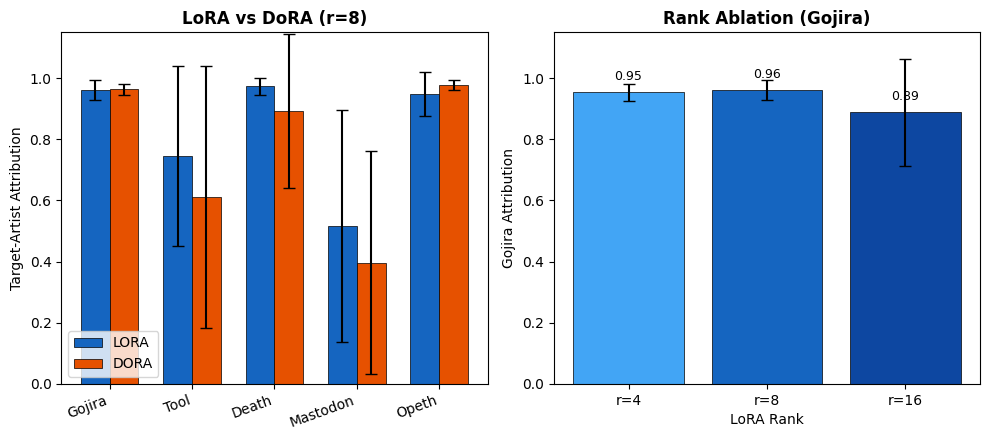

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# LoRA vs DoRA: every artist that has BOTH a lora r8 and dora r8 result.
lora_dora_artists = [
    a for a in ARTISTS
    if Adapter(a, "lora", 8).label in all_results and Adapter(a, "dora", 8).label in all_results
]

ax = axes[0]
x = np.arange(len(lora_dora_artists))
w = 0.35
for i, (kind, color) in enumerate([("lora", "#1565c0"), ("dora", "#e65100")]):
    means, stds = [], []
    for artist in lora_dora_artists:
        d = all_results[Adapter(artist, kind, 8).label]
        means.append(d["df"][d["target"]].mean())
        stds.append(d["df"][d["target"]].std())
    ax.bar(x + i * w, means, w, yerr=stds, capsize=4, label=kind.upper(),
           color=color, edgecolor="black", linewidth=0.5)
ax.set_xticks(x + w / 2)
ax.set_xticklabels(lora_dora_artists, rotation=20, ha="right")
ax.set_ylabel("Target-Artist Attribution")
ax.set_title("LoRA vs DoRA (r=8)", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.15)

# Rank ablation (Gojira): whichever of r=4/8/16 are present.
ax = axes[1]
rank_specs = [s for s in (Adapter("Gojira", "lora", r) for r in (4, 8, 16)) if s.label in all_results]
rank_labels = [f"r={s.rank}" for s in rank_specs]
rank_means = [all_results[s.label]["df"]["Gojira"].mean() for s in rank_specs]
rank_stds = [all_results[s.label]["df"]["Gojira"].std() for s in rank_specs]
bars = ax.bar(rank_labels, rank_means, yerr=rank_stds, capsize=4,
              color=["#42a5f5", "#1565c0", "#0d47a1"][:len(rank_specs)],
              edgecolor="black", linewidth=0.5)
for bar, m in zip(bars, rank_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f"{m:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Gojira Attribution")
ax.set_xlabel("LoRA Rank")
ax.set_title("Rank Ablation (Gojira)", fontweight="bold")
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig("../report/figures/ablation.pdf", bbox_inches="tight", dpi=300)
plt.show()

## Sample Lyrics

Best sample per adapter (highest target-artist attribution).

In [6]:
for name, data in all_results.items():
    target = data["target"]
    best_idx = data["df"][target].idxmax()
    score = data["df"].loc[best_idx, target]
    text = data["samples"][best_idx]
    print(f"{'='*60}")
    print(f"{name} — best sample (attribution: {score:.3f})")
    print(f"{'='*60}")
    print(text[:800])
    print("...\n" if len(text) > 800 else "\n")

Gojira LoRA r=8 — best sample (attribution: 0.976)
You'll see the light of tomorrow
And you will meet your master race
Don't fear to come out from under
The rocks that you have been hiding in


It feels like coming back home now
With this embrace, I feel so safe
But I can hear their laughter growing louder
When they call my name


I've always been there for you
Now is the time to go and get stronger
Face the pain and face the fear
Come out from under the rock where you hide


Your dream is alive
On this island, floating on the wind
All illusions are deadened
There is no place for hate or shame


If only dreams were true
Then you would see all over the world
One day we're gonna change the tide
Bring down these mountains made of stone
We will make new worlds arise
From our own hands and build a better future
The walls surrounding us fall awa
...

Gojira DoRA r=8 — best sample (attribution: 0.977)
You're the only one that knows me
I am always growing, I am so lost now
My vision is clear b